In [70]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [71]:
import os
os.chdir(r'C:\Users\Lenovo\Desktop\Diabetes_Classifier\notebooks')
os.chdir("..")
print(os.getcwd())

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_anomalies import outliersCheck,anomaly_imputer
from src.helperFunc import saveFile


C:\Users\Lenovo\Desktop\Diabetes_Classifier


In [72]:
PATH="data/clean/Diabetes Classifier Clean.csv"
df=pd.read_csv(PATH)
df=df.copy()

In [73]:
df.columns=df.columns.str.strip()
df.shape

(5132, 10)

In [74]:
df['gender']=df['gender'].map({'M':1,'F':0})

In [75]:
gender=df['gender']
df=df.drop('gender',axis=1)
Q1=df.quantile(.25)
Q2=df.quantile(.5)
Q3=df.quantile(.75)

IQR=Q3-Q1

lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
print(lower_bound)
print(upper_bound)

df[(df<lower_bound)|(df>upper_bound)]=np.nan
print(df.shape)
df=anomaly_imputer(df)

age           1.50000
bmi          14.50000
chol          2.30375
tg           -0.87500
hdl           0.34000
ldl           0.62500
cr           22.60000
bun           1.35000
diagnosis    -1.50000
dtype: float64
age           93.50000
bmi           34.50000
chol           7.35375
tg             3.88500
hdl            2.34000
ldl            5.06500
cr           117.00000
bun            8.15000
diagnosis      2.50000
dtype: float64
(5132, 9)


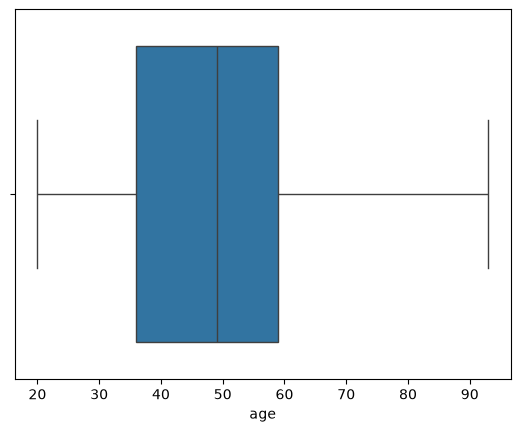

In [76]:
sns.boxplot(x=df['age'])
plt.show()

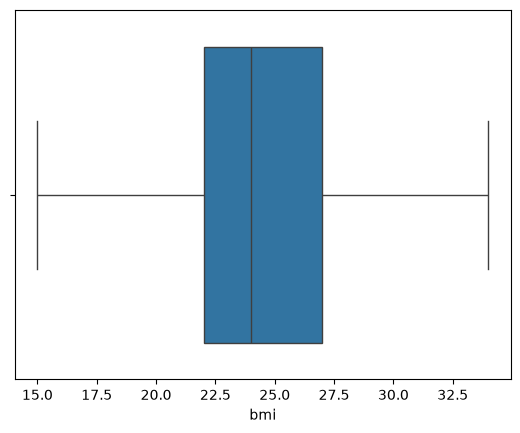

In [77]:
sns.boxplot(x=df['bmi'])
plt.show()

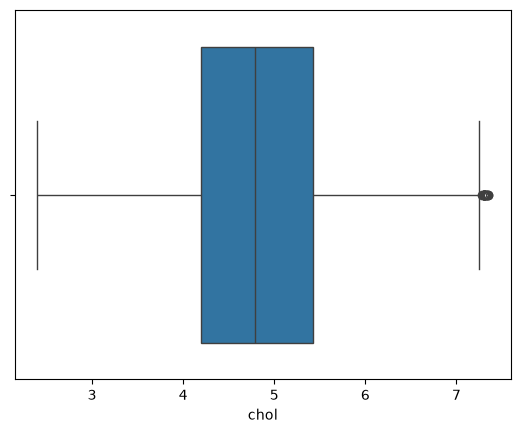

In [78]:
sns.boxplot(x=df['chol'])
plt.show()

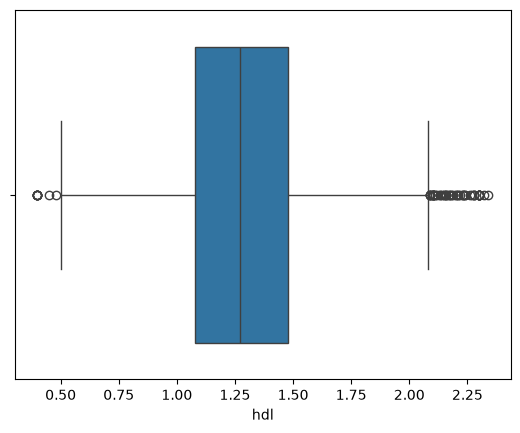

In [79]:
sns.boxplot(x=df['hdl'])
plt.show()

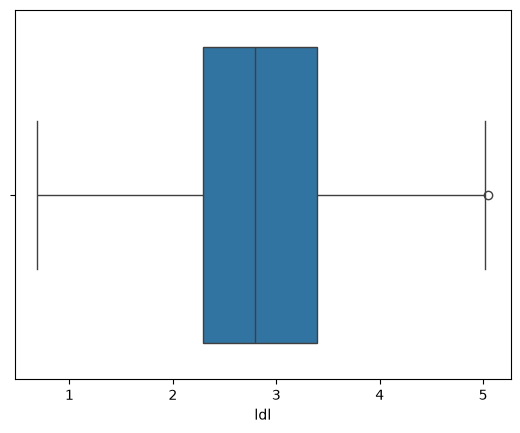

In [80]:
sns.boxplot(x=df['ldl'])
plt.show()

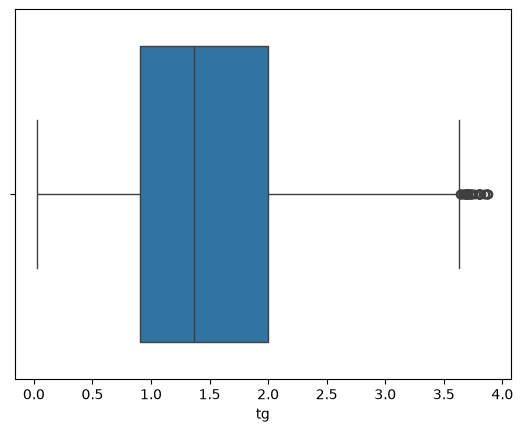

In [81]:
sns.boxplot(x=df['tg'])

plt.show()

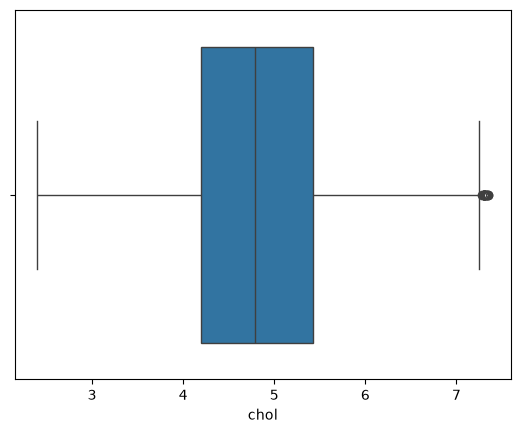

In [82]:

sns.boxplot(x=df['chol'])
plt.show()

(5132, 9)


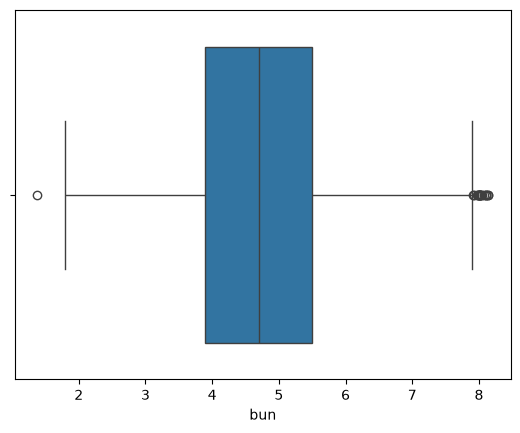

In [83]:
sns.boxplot(x=df['bun'])
print(df.shape)
plt.show()

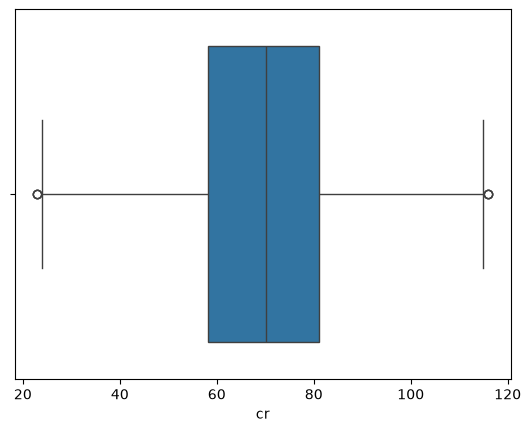

In [84]:
sns.boxplot(x=df['cr'])
plt.show()

In [85]:
print(df[df['cr']>700])

Empty DataFrame
Columns: [age, bmi, chol, tg, hdl, ldl, cr, bun, diagnosis]
Index: []


In [86]:

iso_idx, lof_idx = outliersCheck(df)

df['anomaly_score'] = 0
df.loc[df.index.isin(iso_idx), 'anomaly_score'] += 1
df.loc[df.index.isin(lof_idx), 'anomaly_score'] += 1

ISOLATION FOREST:
Index([   3,    7,   24,   27,   32,   66,   80,   83,   93,  126,
       ...
       4982, 4996, 5011, 5022, 5044, 5058, 5088, 5094, 5108, 5122],
      dtype='int64', length=257)
(257, 10)
LOF:
3      -1
7      -1
15     -1
20     -1
36     -1
       ..
5031   -1
5071   -1
5088   -1
5116   -1
5131   -1
Name: lof_anomalies, Length: 257, dtype: int64
(257,)



In [87]:
df.describe()

,age,bmi,chol,tg,hdl,ldl,cr,bun,diagnosis,anomaly_score
count,5132.000000,5132.000000,5132.000000,5132.000000,5132.000000,5132.000000,5132.000000,5132.000000,5132.000000,5132.000000
mean,48.950312,24.342751,4.830135,1.532093,1.290481,2.902251,69.938583,4.759130,0.388348,0.100156
std,14.048794,3.742693,0.892791,0.780207,0.302082,0.910133,15.909882,1.180739,0.487422,0.339821
min,20.000000,15.000000,2.400000,0.030000,0.400000,0.690000,23.000000,1.380000,0.000000,0.000000
25%,36.000000,22.000000,4.200000,0.910000,1.080000,2.290000,58.100000,3.900000,0.000000,0.000000
50%,49.000000,24.000000,4.790000,1.370000,1.270000,2.790000,70.100000,4.700000,0.000000,0.000000
75%,59.000000,27.000000,5.420000,2.000000,1.480000,3.390000,81.000000,5.500000,1.000000,0.000000
max,93.000000,34.000000,7.350000,3.880000,2.340000,5.050000,116.000000,8.140000,1.000000,2.000000


In [88]:
final=pd.concat([df,gender],axis=1)

In [89]:
final.head()

,age,bmi,chol,tg,hdl,ldl,cr,bun,diagnosis,anomaly_score,gender
0,50.0,24.0,4.2,0.9,1.366,1.4,46.0,4.7,0.0,0,0
1,26.0,23.0,3.7,1.4,1.100,2.1,62.0,4.5,0.0,0,1
2,33.0,21.0,4.9,1.0,0.800,2.0,46.0,7.1,0.0,0,1
3,45.0,21.0,2.9,1.0,1.000,1.5,24.0,2.3,0.0,2,0
4,50.0,24.0,3.6,1.3,0.900,2.1,50.0,2.0,0.0,0,0


In [91]:

saveFile(final,"data/clean/clean2.csv")